# 1.0 — Setup & Imports
Mount Google Drive and import all required standard, third-party, and ML libraries.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Standard library
import io
import json
import os
import random
import time
from pathlib import Path

# Third-party – data / viz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
from openpyxl import Workbook, load_workbook
from openpyxl.drawing.image import Image as XLImage
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

sns.set_style("whitegrid")
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 2.0 — Configuration
All hyper-parameters, paths, and architecture configs are defined here. Change values in this single cell to reconfigure the whole notebook.

In [4]:
# ── Reproducibility ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────
# Folder is named after the current-stage model family (GeoRSCLIP text-head).
MODEL_DIR   = Path("/content/drive/My Drive/Classification/georsclip/models")
RESULTS_DIR = Path("/content/drive/My Drive/Classification/georsclip/results")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR    = RESULTS_DIR / "training_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR     = RESULTS_DIR / "scene_visualizations"
VIS_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR   = Path("/content/drive/My Drive/Classification/data")
DATA_FILE  = DATA_DIR / "data.csv"
LABEL_FILE = DATA_DIR / "ref.csv"

# ── Dataset geometry ──────────────────────────────────────────────────
H, W, B    = 330, 307, 6          # height, width, bands
PATCH_SIZE  = 9
INNER_PATCH = 3                   # tokenisation patch size for Hiera-based branches

# ── Train / val / test splits ─────────────────────────────────────────
TRAIN_PERCENT          = 0.75
VAL_SPLIT_FROM_TRAIN   = 0.20

# ── Training ──────────────────────────────────────────────────────────
BATCH_SIZE    = 128
EPOCHS        = 100
LEARNING_RATE = 3e-4
DROPOUT_RATE  = 0.25
CAPACITY_PRESET = "georsclip_arch"

TRAIN_CFG = {
    "label_smoothing": 0.05,
    "weight_decay":    1e-4,
    "clipnorm":        1.0,
    "cosine_alpha":    0.05,
}

# ── GeoRSCLIP-style text-head config ────────────────────────────────────
# EDIT THESE to real land-cover class names for your site before training —
# the whole point of the text tower is that meaningful prompts let classes
# share vocabulary (e.g. "forest" vs "wetland forest"). Placeholder prompts
# below are generic and carry no real semantic signal until you edit them.
# Order must match your label encoding 1..num_classes.
CLASS_PROMPTS = [
    "a satellite photo of land cover class one",
    "a satellite photo of land cover class two",
    "a satellite photo of land cover class three",
    "a satellite photo of land cover class four",
    "a satellite photo of land cover class five",
    "a satellite photo of land cover class six",
    "a satellite photo of land cover class seven",
]

GEORSCLIP_CFG = {
    "hiera": {"stage_dims": [128, 256], "stage_blocks": [2, 2], "num_heads": 4, "mlp_ratio": 2},
    "proj_dim":        128,
    "text_embed_dim":  64,
    "max_prompt_len":  12,
}

# Fallback config used when Colab runs out of memory
GEORSCLIP_FALLBACK_CFG = {
    "hiera": {"stage_dims": [96, 192], "stage_blocks": [1, 2], "num_heads": 4, "mlp_ratio": 2},
    "proj_dim":        96,
    "text_embed_dim":  48,
    "max_prompt_len":  12,
}

# ── Visualisation palette ─────────────────────────────────────────────
CLASS_COLOR_BASE = [
    "#0000FF", "#00FF00", "#FF0000", "#00FFFF", "#FF00FF",
    "#FFFF00", "#A52A2A", "#FFA500", "#7FFF00", "#8A2BE2",
]
BACKGROUND_COLOR  = "#000000"
VIS_EXCEL_PATH    = VIS_DIR / "initial_classification_maps.xlsx"

print("Data file:    ", DATA_FILE)
print("Label file:   ", LABEL_FILE)
print("Model dir:    ", MODEL_DIR)
print("Results dir:  ", RESULTS_DIR)
print("Plot dir:     ", PLOT_DIR)
print("Arch preset:  ", CAPACITY_PRESET)

Data file:     /content/drive/My Drive/Classification/data/data.csv
Label file:    /content/drive/My Drive/Classification/data/ref.csv
Model dir:     /content/drive/My Drive/Classification/georsclip/models
Results dir:   /content/drive/My Drive/Classification/georsclip/results
Plot dir:      /content/drive/My Drive/Classification/georsclip/results/training_plots
Arch preset:   georsclip_arch


# 3.0 — Data Loading & Preprocessing
Load the raw multispectral CSV files, apply per-band min-max normalisation, extract labelled patches, and create stratified train / val / test splits.

## 3.1 — Loading and patch extraction helpers

In [5]:
def load_multispectral_6band(data_path, label_path, height, width, bands):
    """Load multispectral data and reference labels; normalise each band to [0, 1]."""
    x = pd.read_csv(data_path).to_numpy(dtype=np.float32).reshape(height, width, bands)
    y = pd.read_csv(label_path).to_numpy(dtype=np.int32).reshape(height, width)

    x_norm = np.empty_like(x, dtype=np.float32)
    for b in range(bands):
        band     = x[:, :, b]
        band_min = np.min(band)
        band_max = np.max(band)
        denom    = max(band_max - band_min, 1e-8)
        x_norm[:, :, b] = (band - band_min) / denom

    return x_norm, y


def extract_labeled_patches(x, y, patch_size=9):
    """Extract (patch_size × patch_size) spatial patches around every labelled pixel."""
    pad   = patch_size // 2
    x_pad = np.pad(x, ((pad, pad), (pad, pad), (0, 0)), mode="edge")

    coords  = np.argwhere(y > 0)
    patches = np.empty((coords.shape[0], patch_size, patch_size, x.shape[-1]), dtype=np.float32)
    labels  = np.empty((coords.shape[0],), dtype=np.int32)

    for i, (r, c) in enumerate(coords):
        patches[i] = x_pad[r:r + patch_size, c:c + patch_size, :]
        labels[i]  = int(y[r, c]) - 1  # convert class IDs to 0..C-1

    return patches, labels, coords

## 3.2 — Load data and create splits

In [6]:
x_img, y_img = load_multispectral_6band(DATA_FILE, LABEL_FILE, H, W, B)
X, y, coords = extract_labeled_patches(x_img, y_img, PATCH_SIZE)

num_classes = int(np.unique(y).size)
input_shape = (PATCH_SIZE, PATCH_SIZE, B)

print("x_img:", x_img.shape, "  y_img:", y_img.shape)
print("Labelled samples:", X.shape[0])
print("Patch tensor:    ", X.shape)
print("Num classes:     ", num_classes)

x_img: (330, 307, 6)   y_img: (330, 307)
Labelled samples: 17239
Patch tensor:     (17239, 9, 9, 6)
Num classes:      7


In [7]:
# Stratified split used by GeoRSCLIP_TextHead
x_train_full, x_test, y_train_full, y_test = train_test_split(
    X, y,
    train_size=TRAIN_PERCENT,
    random_state=SEED,
    stratify=y,
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=VAL_SPLIT_FROM_TRAIN,
    random_state=SEED,
    stratify=y_train_full,
)

y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_val_cat   = keras.utils.to_categorical(y_val,   num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)

print("Train:", x_train.shape, y_train.shape)
print("Val:  ", x_val.shape,   y_val.shape)
print("Test: ", x_test.shape,  y_test.shape)

Train: (10343, 9, 9, 6) (10343,)
Val:   (2586, 9, 9, 6) (2586,)
Test:  (4310, 9, 9, 6) (4310,)


# 4.0 — Model Definitions
Defines the GeoRSCLIP-style text-prompt head: a Hiera image tower matched against a small trainable text tower over class-name prompts, combined via a CLIP-style cosine-similarity classifier. Custom Keras layers are registered for serialisation.

## 4.1 — Shared custom Keras layers (PatchExtractor, PatchPositionEncoder, TextPromptEncoder, CosineClassifierHead) and the shared transformer block / Hiera helpers

In [8]:
@tf.keras.utils.register_keras_serializable()
class PatchExtractor(layers.Layer):
    """Extract non-overlapping spatial patches from an image tensor."""

    def __init__(self, patch_size=3, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        patches     = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        batch       = tf.shape(images)[0]
        num_patches = tf.shape(patches)[1] * tf.shape(patches)[2]
        patch_dim   = tf.shape(patches)[-1]
        return tf.reshape(patches, [batch, num_patches, patch_dim])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"patch_size": self.patch_size})
        return cfg


@tf.keras.utils.register_keras_serializable()
class PatchPositionEncoder(layers.Layer):
    """Project patches to embedding dim and add learned positional embeddings."""

    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches      = num_patches
        self.projection_dim   = projection_dim
        self.projection       = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patches) + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"num_patches": self.num_patches, "projection_dim": self.projection_dim})
        return cfg


@tf.keras.utils.register_keras_serializable()
class TextPromptEncoder(layers.Layer):
    """GeoRSCLIP-style text tower.

    Encodes a small, FIXED set of class-name text prompts into embeddings via a
    trainable token embedding + masked mean pooling + MLP projection, L2-
    normalised so cosine similarity with the image embedding forms the
    classification logits (Zhang et al., 2024 — GeoRSCLIP; used as the text
    prompter in LandSegmenter, Liu et al., 2026). The prompt vocabulary is
    fixed at model-build time (token ids baked into layer config) — there is
    no runtime text input, since the class list doesn't change per sample.

    NOTE: this text tower is trained from scratch alongside the image tower
    (no internet access to a pretrained CLIP/GeoRSCLIP checkpoint in this
    environment), so it does not carry external language-vision knowledge.
    """

    def __init__(self, vocab_size, embed_dim, proj_dim, token_ids, pad_id=0, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.embed_dim  = embed_dim
        self.proj_dim   = proj_dim
        self.token_ids  = [list(row) for row in token_ids]  # (K, max_len) python ints
        self.pad_id     = pad_id

    def build(self, input_shape):
        self.token_ids_tensor = tf.constant(self.token_ids, dtype=tf.int32)  # (K, max_len)
        self.token_embed = layers.Embedding(self.vocab_size, self.embed_dim, name=f"{self.name}_tok_embed")
        self.proj1 = layers.Dense(self.proj_dim, activation="gelu", name=f"{self.name}_proj1")
        self.proj2 = layers.Dense(self.proj_dim, name=f"{self.name}_proj2")
        super().build(input_shape)

    def call(self, inputs):
        # `inputs` only anchors this layer in the Keras functional graph; its
        # values are unused since the prompt set is a fixed, build-time constant.
        mask   = tf.cast(tf.not_equal(self.token_ids_tensor, self.pad_id), tf.float32)  # (K, max_len)
        tokens = self.token_embed(self.token_ids_tensor)                                # (K, max_len, embed_dim)
        summed = tf.reduce_sum(tokens * mask[..., None], axis=1)                        # (K, embed_dim)
        counts = tf.maximum(tf.reduce_sum(mask, axis=1, keepdims=True), 1.0)            # (K, 1)
        pooled = summed / counts                                                        # (K, embed_dim)
        x = self.proj2(self.proj1(pooled))                                              # (K, proj_dim)
        return tf.math.l2_normalize(x, axis=-1)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "vocab_size": self.vocab_size, "embed_dim": self.embed_dim,
            "proj_dim": self.proj_dim, "token_ids": self.token_ids, "pad_id": self.pad_id,
        })
        return cfg


@tf.keras.utils.register_keras_serializable()
class CosineClassifierHead(layers.Layer):
    """CLIP-style cosine-similarity classifier.

    L2-normalises the image embedding, computes cosine similarity against
    each class's text embedding, and scales by a learnable temperature
    (logit_scale) before softmax — the standard way CLIP zero-shot
    classification heads are trained and used.
    """

    def __init__(self, init_logit_scale=4.6, **kwargs):  # ln(100) ≈ 4.6, CLIP's default init
        super().__init__(**kwargs)
        self.init_logit_scale = init_logit_scale

    def build(self, input_shape):
        self.logit_scale = self.add_weight(
            name="logit_scale", shape=(),
            initializer=tf.keras.initializers.Constant(self.init_logit_scale),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        image_embed, text_embed = inputs
        image_embed = tf.math.l2_normalize(image_embed, axis=-1)
        logits = tf.matmul(image_embed, text_embed, transpose_b=True)  # (B, K)
        return logits * tf.exp(self.logit_scale)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"init_logit_scale": self.init_logit_scale})
        return cfg


def build_prompt_vocab(class_prompts):
    """Build a word -> id vocabulary from the class prompt strings. 0=PAD, 1=UNK."""
    vocab = {"<pad>": 0, "<unk>": 1}
    for prompt in class_prompts:
        for word in prompt.lower().split():
            if word not in vocab:
                vocab[word] = len(vocab)
    return vocab


def tokenize_class_prompts(class_prompts, vocab, max_len):
    """Convert class prompt strings to a padded (K, max_len) list-of-lists of token ids."""
    token_ids = []
    for prompt in class_prompts:
        ids = [vocab.get(word, vocab["<unk>"]) for word in prompt.lower().split()]
        ids = ids[:max_len] + [vocab["<pad>"]] * max(0, max_len - len(ids))
        token_ids.append(ids)
    return token_ids


def transformer_block(x, num_heads, projection_dim, mlp_dim, dropout_rate, name_prefix):
    """Standard pre-LN transformer block with multi-head attention and a GELU MLP."""
    y = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_ln1")(x)
    y = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim,
        dropout=dropout_rate, name=f"{name_prefix}_mha",
    )(y, y)
    x = layers.Add(name=f"{name_prefix}_add1")([y, x])

    y = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_ln2")(x)
    y = layers.Dense(mlp_dim, activation=tf.keras.activations.gelu, name=f"{name_prefix}_mlp1")(y)
    y = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop1")(y)
    y = layers.Dense(projection_dim, activation=tf.keras.activations.gelu, name=f"{name_prefix}_mlp2")(y)
    y = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop2")(y)
    return layers.Add(name=f"{name_prefix}_add2")([y, x])


def hiera_merge_tokens(x, token_side, dim_out, name_prefix):
    """Patch-merging step between Hiera stages: reshape tokens back to a grid,
    2x2-pool (with edge padding if the side is odd), then project channels up.
    """
    x   = layers.Reshape((token_side, token_side, -1), name=f"{name_prefix}_to_grid")(x)
    pad = token_side % 2
    if pad:
        x = layers.ZeroPadding2D(padding=((0, pad), (0, pad)), name=f"{name_prefix}_pad")(x)
    x = layers.AveragePooling2D(pool_size=2, name=f"{name_prefix}_pool")(x)
    x = layers.Conv2D(dim_out, 1, activation="gelu", name=f"{name_prefix}_proj")(x)
    new_side = (token_side + pad) // 2
    x = layers.Reshape((new_side * new_side, dim_out), name=f"{name_prefix}_to_tokens")(x)
    return x, new_side


def hiera_spatial_branch(inputs, inner_patch, cfg, dropout_rate, name_prefix="hiera"):
    """Hiera-inspired hierarchical transformer branch: tokenise, run transformer
    blocks per stage, and patch-merge between stages (Ravi et al., 2024 —
    SAM2/Hiera). Used here as the GeoRSCLIP_TextHead image tower.
    """
    token_side  = inputs.shape[1] // inner_patch
    num_patches = token_side * token_side

    x = PatchExtractor(inner_patch, name=f"{name_prefix}_patch_extractor")(inputs)
    x = PatchPositionEncoder(num_patches, cfg["stage_dims"][0], name=f"{name_prefix}_patch_encoder")(x)
    x = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop0")(x)

    for stage_idx, (dim, n_blocks) in enumerate(zip(cfg["stage_dims"], cfg["stage_blocks"]), start=1):
        prefix = f"{name_prefix}_stage{stage_idx}"
        if stage_idx > 1:
            x, token_side = hiera_merge_tokens(x, token_side, dim, name_prefix=f"{prefix}_merge")
        for b in range(n_blocks):
            x = transformer_block(
                x, num_heads=cfg["num_heads"], projection_dim=dim,
                mlp_dim=dim * cfg["mlp_ratio"], dropout_rate=dropout_rate,
                name_prefix=f"{prefix}_blk{b + 1}",
            )

    x = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_final_ln")(x)
    x = layers.GlobalAveragePooling1D(name=f"{name_prefix}_gap")(x)
    x = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop_final")(x)
    return x

## 4.2 — GeoRSCLIP-style text-prompt head

Image tower is a Hiera hierarchical branch, matched against a small trainable text tower that encodes the `CLASS_PROMPTS` strings from Section 2.0, following LandSegmenter's text-prompter design. Classification is cosine similarity between the image embedding and each class's text embedding, scaled by a learnable temperature (CLIP-style).

**Important:** there is no internet access to a pretrained CLIP/GeoRSCLIP checkpoint in this environment, so the text tower is trained from scratch on your `CLASS_PROMPTS` alongside the image tower — it does **not** carry external language-vision pretraining, so don't expect true zero-shot transfer to class names never seen during training. What you do get: a prompt-conditioned classification head where editing `CLASS_PROMPTS` (e.g. real land-cover names) changes what the model is being asked to predict, and where classes that share vocabulary can share representation.

In [9]:
def build_georsclip_texthead(input_shape, num_classes, class_prompts, inner_patch=3,
                              dropout_rate=0.25, cfg=None):
    """Build the GeoRSCLIP-style text-conditioned classifier: a Hiera image tower
    + a small trainable text tower over `class_prompts`, combined via a
    CLIP-style cosine-similarity classifier head.
    """
    cfg   = cfg or GEORSCLIP_CFG
    vocab = build_prompt_vocab(class_prompts)
    token_ids = tokenize_class_prompts(class_prompts, vocab, max_len=cfg["max_prompt_len"])

    inputs = keras.Input(shape=input_shape)

    img_feat    = hiera_spatial_branch(inputs, inner_patch, cfg["hiera"], dropout_rate, name_prefix="clip_img")
    image_embed = layers.Dense(cfg["proj_dim"], name="clip_image_proj")(img_feat)

    text_embed = TextPromptEncoder(
        vocab_size=len(vocab), embed_dim=cfg["text_embed_dim"], proj_dim=cfg["proj_dim"],
        token_ids=token_ids, name="clip_text_encoder",
    )(inputs)  # `inputs` only anchors the layer in the graph; values are unused

    logits  = CosineClassifierHead(name="clip_cosine_head")([image_embed, text_embed])
    outputs = layers.Softmax(name="georsclip_probs")(logits)
    return keras.Model(inputs, outputs, name="GeoRSCLIP_TextHead")

# 5.0 — Training & Evaluation Helpers
Optimiser factory, learning-rate schedule, calibration metrics (Brier score, ECE), and the main `train_save_evaluate` function.

## 5.1 — Calibration metrics

In [10]:
def multiclass_brier_score(y_onehot, y_prob):
    """Compute the multiclass Brier score (mean squared error over probability vectors)."""
    return float(np.mean(np.sum((y_prob - y_onehot) ** 2, axis=1)))


def expected_calibration_error(y_true, y_prob, n_bins=15):
    """Compute Expected Calibration Error (ECE) with equal-width confidence bins."""
    confidences = np.max(y_prob, axis=1)
    predictions = np.argmax(y_prob, axis=1)
    correct     = (predictions == y_true).astype(np.float32)
    bin_edges   = np.linspace(0.0, 1.0, n_bins + 1)
    ece         = 0.0

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        in_bin = (confidences >= lo) & (confidences <= hi if i == n_bins - 1 else confidences < hi)
        prop   = np.mean(in_bin)
        if prop > 0:
            ece += np.abs(np.mean(correct[in_bin]) - np.mean(confidences[in_bin])) * prop

    return float(ece)

## 5.2 — Optimiser factory

In [11]:
def make_optimizer(num_train_samples):
    """Build an AdamW optimiser with a cosine-decay learning-rate schedule."""
    steps_per_epoch = int(np.ceil(num_train_samples / BATCH_SIZE))
    decay_steps     = max(1, steps_per_epoch * EPOCHS)
    lr_schedule     = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LEARNING_RATE,
        decay_steps=decay_steps,
        alpha=TRAIN_CFG["cosine_alpha"],
    )
    return keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=TRAIN_CFG["weight_decay"],
        clipnorm=TRAIN_CFG["clipnorm"],
    )

## 5.3 — Main training, saving, and evaluation function

In [12]:
def train_save_evaluate(model_name, model_builder, capacity_tag="max"):
    """Compile, train, save (best + final), and evaluate a single-head model.

    Returns a metrics dict, per-class classification report, confusion matrix,
    and the raw Keras history dict.
    """
    tf.keras.backend.clear_session()
    model      = model_builder()
    best_path  = MODEL_DIR / f"{model_name}_best.keras"
    final_path = MODEL_DIR / f"{model_name}_final.keras"

    # All four models share the same AdamW + cosine-decay + label-smoothing recipe.
    model.compile(
        optimizer=make_optimizer(len(x_train)),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=TRAIN_CFG["label_smoothing"]),
        metrics=["accuracy"],
    )
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=str(best_path), monitor="val_loss",
            mode="min", save_best_only=True, verbose=1,
        ),
    ]
    x_tr, y_tr           = x_train, y_train_cat
    x_va, y_va           = x_val,   y_val_cat
    x_te, y_te, y_te_cat = x_test, y_test, y_test_cat
    x_eval, y_eval, y_eval_cat = x_val, y_val, y_val_cat

    train_start = time.perf_counter()
    history_obj = model.fit(
        x_tr, y_tr,
        validation_data=(x_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
        shuffle=True,
    )
    train_time_sec = float(time.perf_counter() - train_start)

    epochs_ran = int(len(history_obj.history.get("loss", [])))
    if epochs_ran != EPOCHS:
        print(f"WARNING: {model_name} ran {epochs_ran} epochs, expected {EPOCHS}.")
    else:
        print(f"{model_name} completed full training: {epochs_ran}/{EPOCHS} epochs.")

    model.save(final_path)

    y_eval_prob = model.predict(x_eval, batch_size=BATCH_SIZE, verbose=0)
    y_test_prob = model.predict(x_te,   batch_size=BATCH_SIZE, verbose=0)
    y_test_pred = np.argmax(y_test_prob, axis=1)

    report = classification_report(y_te, y_test_pred, output_dict=True, zero_division=0)
    cm     = confusion_matrix(y_te, y_test_pred)

    row = {
        "model":            model_name,
        "capacity_tag":     capacity_tag,
        "test_accuracy":    float(accuracy_score(y_te, y_test_pred)),
        "kappa":            float(cohen_kappa_score(y_te, y_test_pred)),
        "macro_f1":         float(f1_score(y_te, y_test_pred, average="macro")),
        "weighted_f1":      float(f1_score(y_te, y_test_pred, average="weighted")),
        "val_nll":          float(log_loss(y_eval, y_eval_prob, labels=np.arange(num_classes))),
        "test_nll":         float(log_loss(y_te,   y_test_prob, labels=np.arange(num_classes))),
        "val_brier":        multiclass_brier_score(y_eval_cat, y_eval_prob),
        "test_brier":       multiclass_brier_score(y_te_cat,   y_test_prob),
        "test_ece_15bin":   expected_calibration_error(y_te, y_test_prob, n_bins=15),
        "epochs_configured": int(EPOCHS),
        "epochs_ran":       epochs_ran,
        "train_time_sec":   train_time_sec,
        "best_model_path":  str(best_path),
        "final_model_path": str(final_path),
    }
    return row, report, cm, history_obj.history

# 6.0 — Model Training
Builds and trains GeoRSCLIP_TextHead. An OOM error automatically retries with a reduced fallback config.

In [13]:
def build_georsclip_with_cfg(cfg):
    """Instantiate GeoRSCLIP_TextHead from a config dict."""
    return build_georsclip_texthead(
        input_shape, num_classes, CLASS_PROMPTS,
        inner_patch=INNER_PATCH,
        dropout_rate=DROPOUT_RATE,
        cfg=cfg,
    )


model_builders = {
    "GeoRSCLIP_TextHead": lambda: build_georsclip_with_cfg(GEORSCLIP_CFG),
}

In [14]:
results_rows   = []
model_artifacts = {}

for model_name, builder in model_builders.items():
    print(f"\n{'=' * 25} Training {model_name} ({CAPACITY_PRESET}) {'=' * 25}")

    try:
        row, report, cm, history = train_save_evaluate(model_name, builder,
                                                       capacity_tag=CAPACITY_PRESET)
    except tf.errors.ResourceExhaustedError:
        # Automatically retry with a smaller fallback config to handle Colab OOM
        if model_name == "GeoRSCLIP_TextHead":
            print("OOM on GeoRSCLIP_TextHead default config. Retrying with fallback config.")
            tf.keras.backend.clear_session()
            row, report, cm, history = train_save_evaluate(
                model_name, lambda: build_georsclip_with_cfg(GEORSCLIP_FALLBACK_CFG),
                capacity_tag="fallback",
            )
        else:
            raise

    results_rows.append(row)
    model_artifacts[model_name] = {"report": report, "confusion_matrix": cm, "history": history}

summary_df = (
    pd.DataFrame(results_rows)
    .sort_values("test_accuracy", ascending=False)
    .reset_index(drop=True)
)
summary_df


========================= Training GeoRSCLIP_TextHead (georsclip_arch) =========================
Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.4821 - loss: 1.8757
Epoch 1: val_loss improved from None to 1.00655, saving model to /content/drive/My Drive/Classification/georsclip/models/GeoRSCLIP_TextHead_best.keras

Epoch 1: finished saving model to /content/drive/My Drive/Classification/georsclip/models/GeoRSCLIP_TextHead_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 79s 432ms/step - accuracy: 0.5542 - loss: 1.3473 - val_accuracy: 0.6589 - val_loss: 1.0065
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6839 - loss: 0.9559
Epoch 2: val_loss improved from 1.00655 to 0.70107, saving model to /content/drive/My Drive/Classification/georsclip/models/GeoRSCLIP_TextHead_best.keras

Epoch 2: finished saving model to /content/drive/My Drive/Classification/georsclip/models/GeoRSCLIP_TextHead_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.7063 - los

,model,capacity_tag,test_accuracy,kappa,macro_f1,weighted_f1,val_nll,test_nll,val_brier,test_brier,test_ece_15bin,epochs_configured,epochs_ran,train_time_sec,best_model_path,final_model_path
0,GeoRSCLIP_TextHead,georsclip_arch,0.996288,0.994966,0.995224,0.996288,0.040906,0.045911,0.004558,0.007413,0.035338,100,100,376.080761,/content/drive/My Drive/Classification/georscl...,/content/drive/My Drive/Classification/georscl...


# 7.0 — Results & Metrics
Save classification summaries to CSV / JSON, then plot training curves, cross-model bar charts, calibration proxies, and confusion matrices.

## 7.1 — Save summary CSV and per-model JSON reports

In [15]:
summary_path = RESULTS_DIR / "classification_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved summary:", summary_path)

for model_name, artifact in model_artifacts.items():
    report_path = RESULTS_DIR / f"{model_name}_classification_report.json"
    with open(report_path, "w", encoding="utf-8") as f:
        json.dump(artifact["report"], f, indent=2)

print("Per-model classification reports saved to:", RESULTS_DIR)
summary_df

Saved summary: /content/drive/My Drive/Classification/georsclip/results/classification_summary.csv
Per-model classification reports saved to: /content/drive/My Drive/Classification/georsclip/results


,model,capacity_tag,test_accuracy,kappa,macro_f1,weighted_f1,val_nll,test_nll,val_brier,test_brier,test_ece_15bin,epochs_configured,epochs_ran,train_time_sec,best_model_path,final_model_path
0,GeoRSCLIP_TextHead,georsclip_arch,0.996288,0.994966,0.995224,0.996288,0.040906,0.045911,0.004558,0.007413,0.035338,100,100,376.080761,/content/drive/My Drive/Classification/georscl...,/content/drive/My Drive/Classification/georscl...


## 7.2 — Training curves (accuracy and loss per epoch)

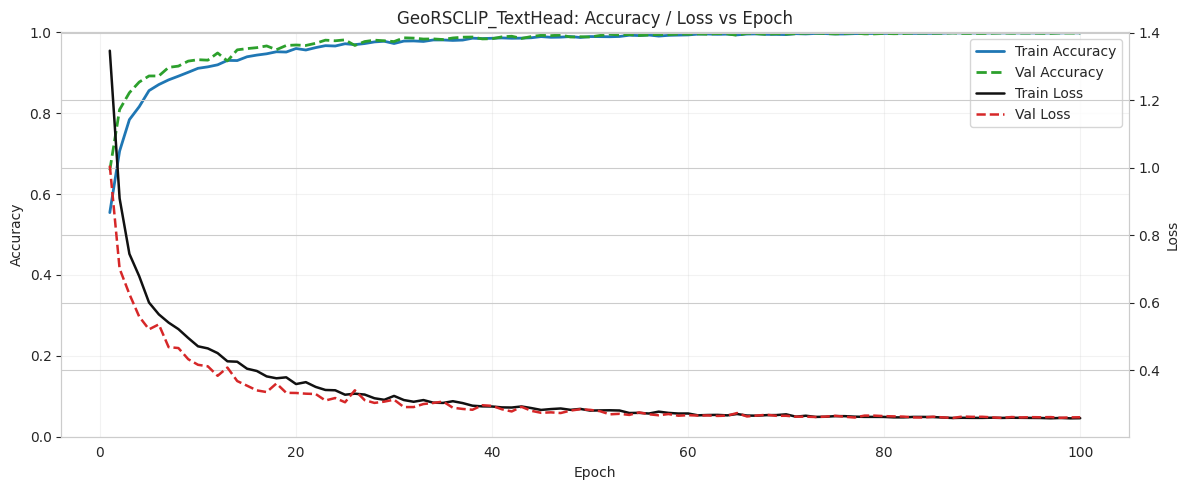

In [16]:
for model_name, artifact in model_artifacts.items():
    hist   = artifact["history"]
    epochs = np.arange(1, len(hist["loss"]) + 1)

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(epochs, hist["accuracy"],     color="#1f77b4", linewidth=2,   label="Train Accuracy")
    ax1.plot(epochs, hist["val_accuracy"], color="#2ca02c", linewidth=2, linestyle="--", label="Val Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.set_ylim(0, 1.0)
    ax1.grid(True, alpha=0.25)

    ax2 = ax1.twinx()
    ax2.plot(epochs, hist["loss"],     color="#111111", linewidth=1.8,   label="Train Loss")
    ax2.plot(epochs, hist["val_loss"], color="#d62728", linewidth=1.8, linestyle="--", label="Val Loss")
    ax2.set_ylabel("Loss")

    lines  = ax1.get_lines() + ax2.get_lines()
    labels = [ln.get_label() for ln in lines]
    ax1.legend(lines, labels, loc="upper right", frameon=True)
    plt.title(f"{model_name}: Accuracy / Loss vs Epoch")
    plt.tight_layout()

    curve_path = PLOT_DIR / f"{model_name}_training_curves.png"
    plt.savefig(curve_path, dpi=200, bbox_inches="tight")
    plt.show()

## 7.3 — Cross-model comparison bar charts

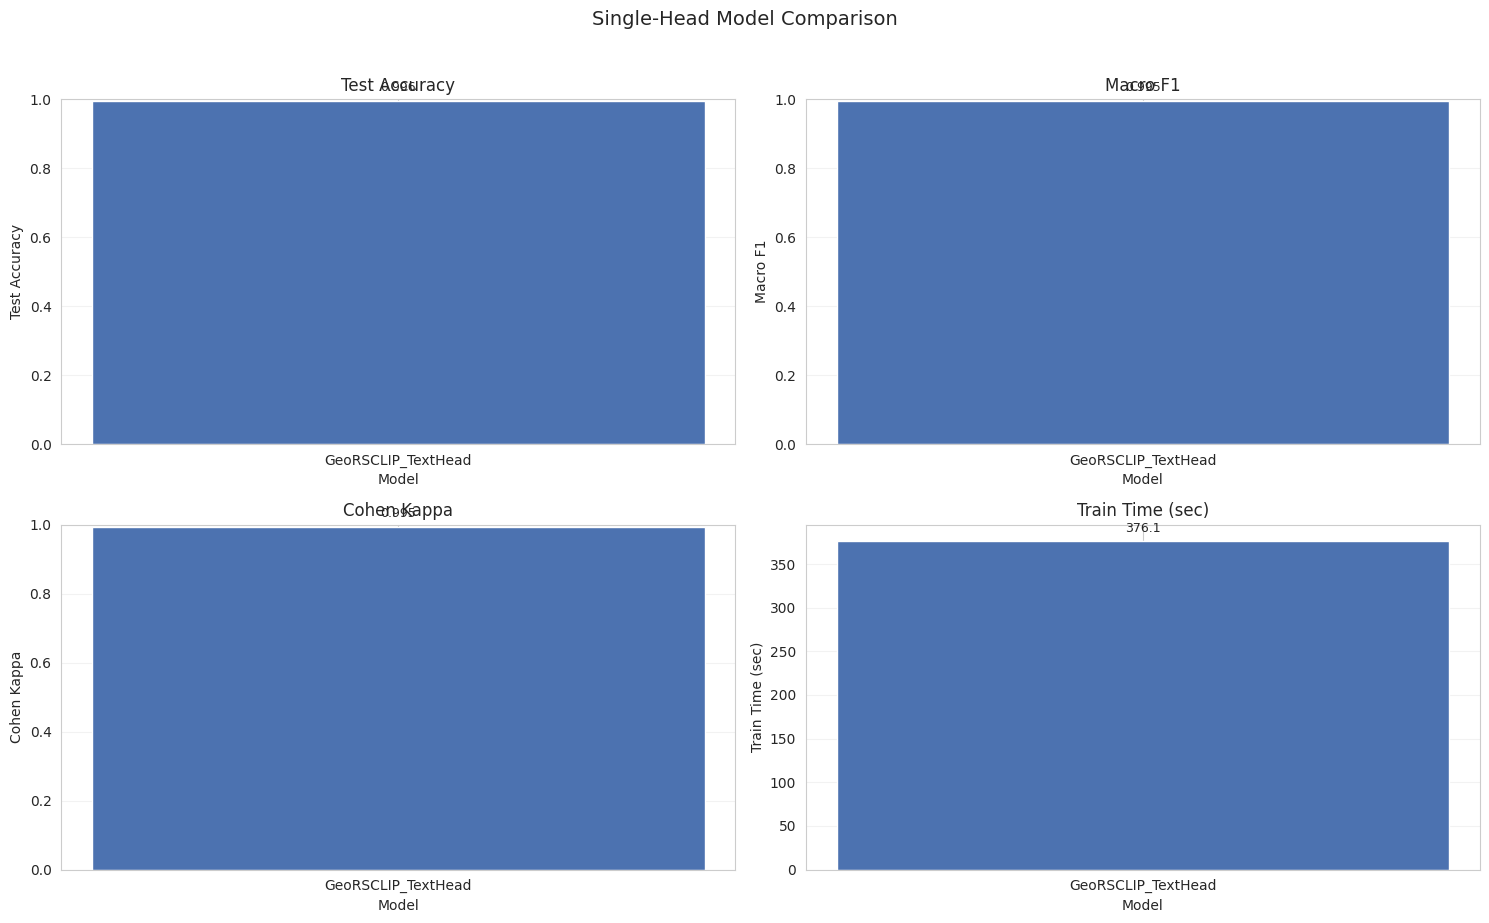

In [17]:
plot_df = summary_df[[
    "model", "test_accuracy", "macro_f1", "kappa", "train_time_sec",
    "test_nll", "test_brier", "test_ece_15bin",
]].copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes    = axes.flatten()
palette = ["#4c72b0", "#55a868", "#c44e52"]

metric_specs = [
    ("test_accuracy",  "Test Accuracy",   (0.0, 1.0), "{:.3f}"),
    ("macro_f1",       "Macro F1",        (0.0, 1.0), "{:.3f}"),
    ("kappa",          "Cohen Kappa",     (0.0, 1.0), "{:.3f}"),
    ("train_time_sec", "Train Time (sec)", None,       "{:.1f}"),
]

for ax, (col, title, ylim, fmt) in zip(axes, metric_specs):
    local = plot_df[["model", col]].copy()
    bars  = ax.bar(local["model"], local[col], color=palette[:len(local)])
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.25)
    for patch in bars:
        height = patch.get_height()
        xpos   = patch.get_x() + patch.get_width() / 2
        offset = (ylim[1] - ylim[0]) * 0.02 if ylim else max(local[col].max() * 0.02, 0.05)
        ax.text(xpos, height + offset, fmt.format(height), ha="center", va="bottom", fontsize=9)

plt.suptitle("Single-Head Model Comparison", y=1.02, fontsize=14)
plt.tight_layout()
comparison_path = PLOT_DIR / "model_comparison_metrics.png"
plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
plt.show()

## 7.4 — Calibration proxy metrics and confusion matrices

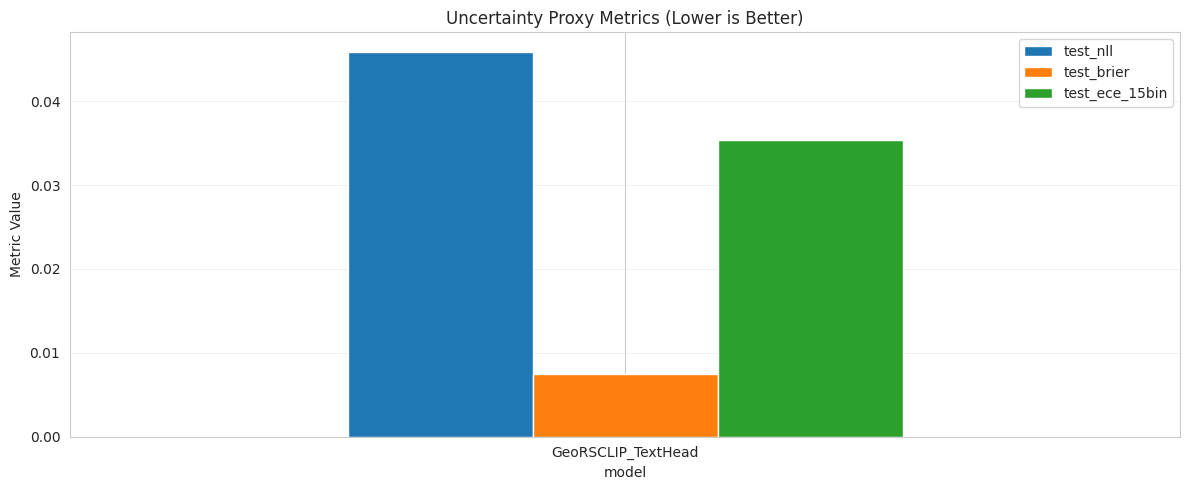

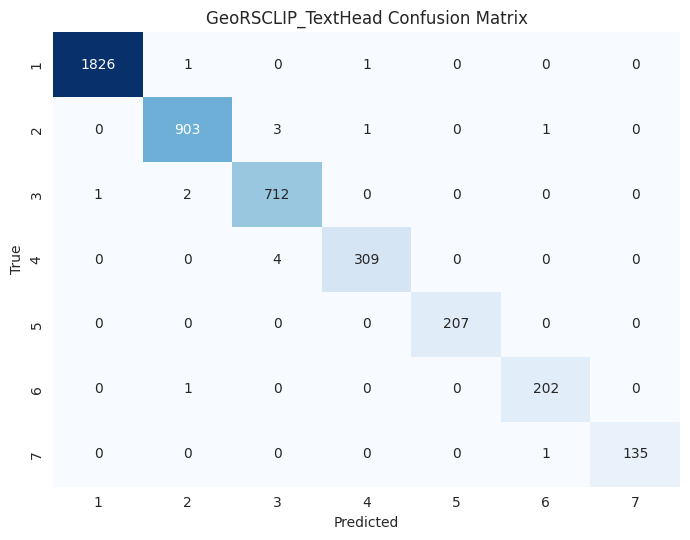

Saved confusion matrix figure: /content/drive/My Drive/Classification/georsclip/results/training_plots/confusion_matrices_side_by_side.png
All training plots saved to: /content/drive/My Drive/Classification/georsclip/results/training_plots


In [18]:
# Calibration proxy chart (lower is better for all three metrics)
fig, ax     = plt.subplots(figsize=(12, 5))
calib_cols  = ["test_nll", "test_brier", "test_ece_15bin"]
calib_df    = plot_df[["model"] + calib_cols].set_index("model")
calib_df.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Uncertainty Proxy Metrics (Lower is Better)")
ax.set_ylabel("Metric Value")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
calib_path = PLOT_DIR / "uncertainty_proxy_metrics.png"
plt.savefig(calib_path, dpi=200, bbox_inches="tight")
plt.show()

# Side-by-side confusion matrices
class_ticks = [str(i + 1) for i in range(num_classes)]
fig, axes   = plt.subplots(1, len(model_artifacts), figsize=(7 * len(model_artifacts), 5.5))
if len(model_artifacts) == 1:
    axes = [axes]

for ax, (model_name, artifact) in zip(axes, model_artifacts.items()):
    sns.heatmap(
        artifact["confusion_matrix"],
        annot=True, fmt="d", cmap="Blues",
        xticklabels=class_ticks, yticklabels=class_ticks,
        cbar=False, ax=ax,
    )
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
cm_path = PLOT_DIR / "confusion_matrices_side_by_side.png"
plt.savefig(cm_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved confusion matrix figure:", cm_path)
print("All training plots saved to:", PLOT_DIR)

# 8.0 — Scene Visualisation
Load the saved best models, run dense patch-by-patch inference over the entire scene, and save classified maps as PNGs and an Excel workbook.

## 8.1 — Visualisation helpers

In [19]:
CUSTOM_OBJECTS = {
    "PatchExtractor":       PatchExtractor,
    "PatchPositionEncoder": PatchPositionEncoder,
    "TextPromptEncoder":    TextPromptEncoder,
    "CosineClassifierHead": CosineClassifierHead,
}


def get_scene_rgb(x_img, bands):
    """Select three bands as an approximate RGB composite; clip to [0, 1]."""
    if bands >= 6:
        rgb_idx = [bands // 2 - 1, bands // 2, bands // 2 + 1]
    elif bands >= 3:
        rgb_idx = [0, 1, 2]
    else:
        raise ValueError(f"Need at least 3 bands to form RGB, got {bands}.")
    return np.clip(x_img[:, :, rgb_idx], 0.0, 1.0)


def get_display_cmap(num_classes):
    """Build a ListedColormap: index 0 = background black, 1..K = class colours."""
    return ListedColormap([BACKGROUND_COLOR] + CLASS_COLOR_BASE[:num_classes])


def predict_full_scene_labels(model, x_img, patch_size=9, batch_size=256):
    """Run dense sliding-window inference row-by-row; returns a (H, W) label map."""
    pad   = patch_size // 2
    x_pad = np.pad(x_img, ((pad, pad), (pad, pad), (0, 0)), mode="edge")
    preds = np.zeros((x_img.shape[0], x_img.shape[1]), dtype=np.int32)

    for r in range(x_img.shape[0]):
        row_patches = np.empty(
            (x_img.shape[1], patch_size, patch_size, x_img.shape[-1]),
            dtype=np.float32,
        )
        for c in range(x_img.shape[1]):
            row_patches[c] = x_pad[r:r + patch_size, c:c + patch_size, :]

        row_prob  = model.predict(row_patches, batch_size=batch_size, verbose=0)
        preds[r]  = np.argmax(row_prob, axis=1) + 1  # back to 1..K

    return preds


def load_saved_models_for_visualization(model_dir, custom_objects):
    """Attempt to load all three best models; return dicts of loaded and missing."""
    model_files = {
        "GeoRSCLIP_TextHead": model_dir / "GeoRSCLIP_TextHead_best.keras",
    }
    loaded, missing = {}, {}
    for model_key, model_path in model_files.items():
        if not model_path.exists():
            missing[model_key] = f"Missing file: {model_path}"
            continue
        try:
            loaded[model_key] = keras.models.load_model(
                model_path, custom_objects=custom_objects,
                compile=False, safe_mode=False,
            )
        except Exception as exc:
            missing[model_key] = f"Load failed: {exc}"
    return loaded, missing


def save_single_panel(image, title, save_path, cmap=None, vmin=None, vmax=None):
    """Save a single image panel as a high-DPI PNG."""
    fig, ax = plt.subplots(figsize=(8, 6))
    if cmap is None:
        ax.imshow(image)
    else:
        ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=14)
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", save_path)


def save_combined_overview(rgb_image, y_true, pred_maps, missing_info, num_classes, save_path):
    """Save a five-panel side-by-side overview: RGB, GT, and one panel per model."""
    cmap   = get_display_cmap(num_classes)
    panels = [
        ("Approximate RGB",                            rgb_image,                            "rgb"),
        ("True Label Map",                             y_true,                               "label"),
        ("GeoRSCLIP Text-Head Initial Classification",  pred_maps.get("GeoRSCLIP_TextHead"), "label"),
    ]

    fig, axes = plt.subplots(1, len(panels), figsize=(30, 7), sharex=True, sharey=True)
    for ax, (title, img, kind) in zip(axes, panels):
        ax.set_title(title, fontsize=13)
        if kind == "rgb":
            ax.imshow(img)
        elif img is None:
            ax.imshow(np.zeros_like(y_true), cmap=cmap, vmin=0, vmax=num_classes)
            key = {"GeoRSCLIP Text-Head": "GeoRSCLIP_TextHead"}.get(
                next((k for k in ("GeoRSCLIP Text-Head",) if k in title), None)
            )
            ax.text(0.5, 0.5, missing_info.get(key, "Unavailable"),
                    ha="center", va="center", fontsize=10, wrap=True, transform=ax.transAxes)
        else:
            ax.imshow(img, cmap=cmap, vmin=0, vmax=num_classes)
        ax.axis("off")

    handles = [plt.Rectangle((0, 0), 1, 1, color=BACKGROUND_COLOR, label="Background")]
    for i in range(num_classes):
        handles.append(plt.Rectangle((0, 0), 1, 1, color=CLASS_COLOR_BASE[i], label=f"Class {i+1}"))
    fig.legend(handles=handles, loc="lower center", ncol=min(num_classes + 1, 8),
               bbox_to_anchor=(0.5, -0.02), frameon=True)
    fig.tight_layout(rect=[0, 0.05, 1, 1])
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", save_path)


def save_images_to_excel(excel_path, image_paths, sheet_name="Initial_Classification_Maps"):
    """Embed PNG images into an Excel workbook at fixed anchor positions."""
    if excel_path.exists():
        wb = load_workbook(excel_path)
        if sheet_name in wb.sheetnames:
            del wb[sheet_name]
        ws = wb.create_sheet(title=sheet_name)
    else:
        wb = Workbook()
        ws = wb.active
        ws.title = sheet_name

    anchors = ["A1", "J1", "A25", "J25", "A49", "J49"]
    for path, anchor in zip(image_paths, anchors):
        if path.exists():
            img        = XLImage(str(path))
            img.anchor = anchor
            ws.add_image(img)

    wb.save(excel_path)
    print("Saved Excel workbook:", excel_path)

## 8.2 — Generate and save all scene maps

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'clip_img_patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Generating full-scene classified image for GeoRSCLIP_TextHead...
GeoRSCLIP_TextHead map shape: (330, 307)


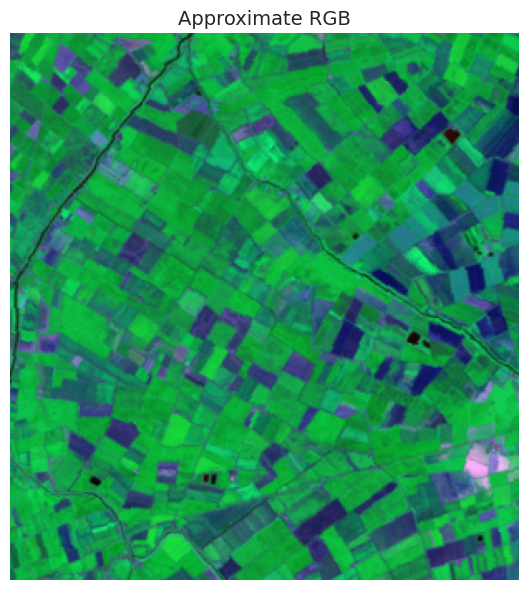

Saved: /content/drive/My Drive/Classification/georsclip/results/scene_visualizations/scene_rgb.png


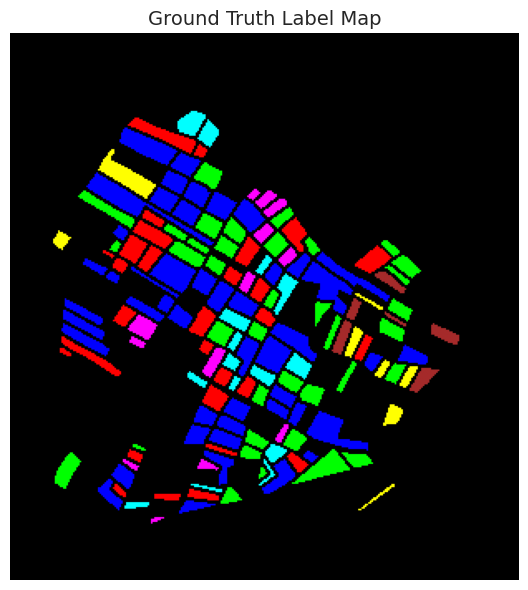

Saved: /content/drive/My Drive/Classification/georsclip/results/scene_visualizations/ground_truth_label_map.png


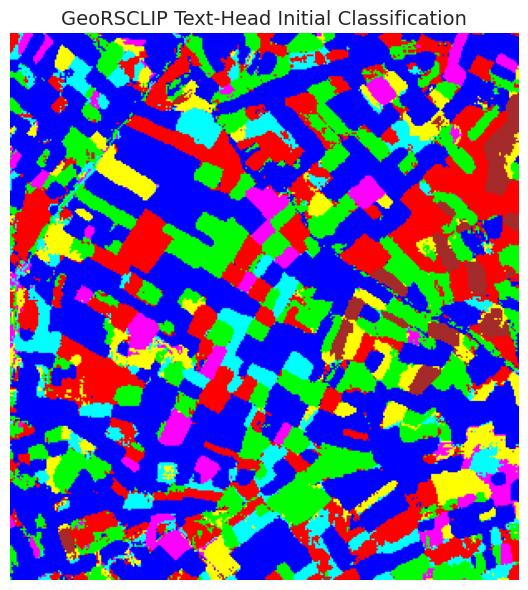

Saved: /content/drive/My Drive/Classification/georsclip/results/scene_visualizations/GeoRSCLIP_TextHead_initial_classification.png


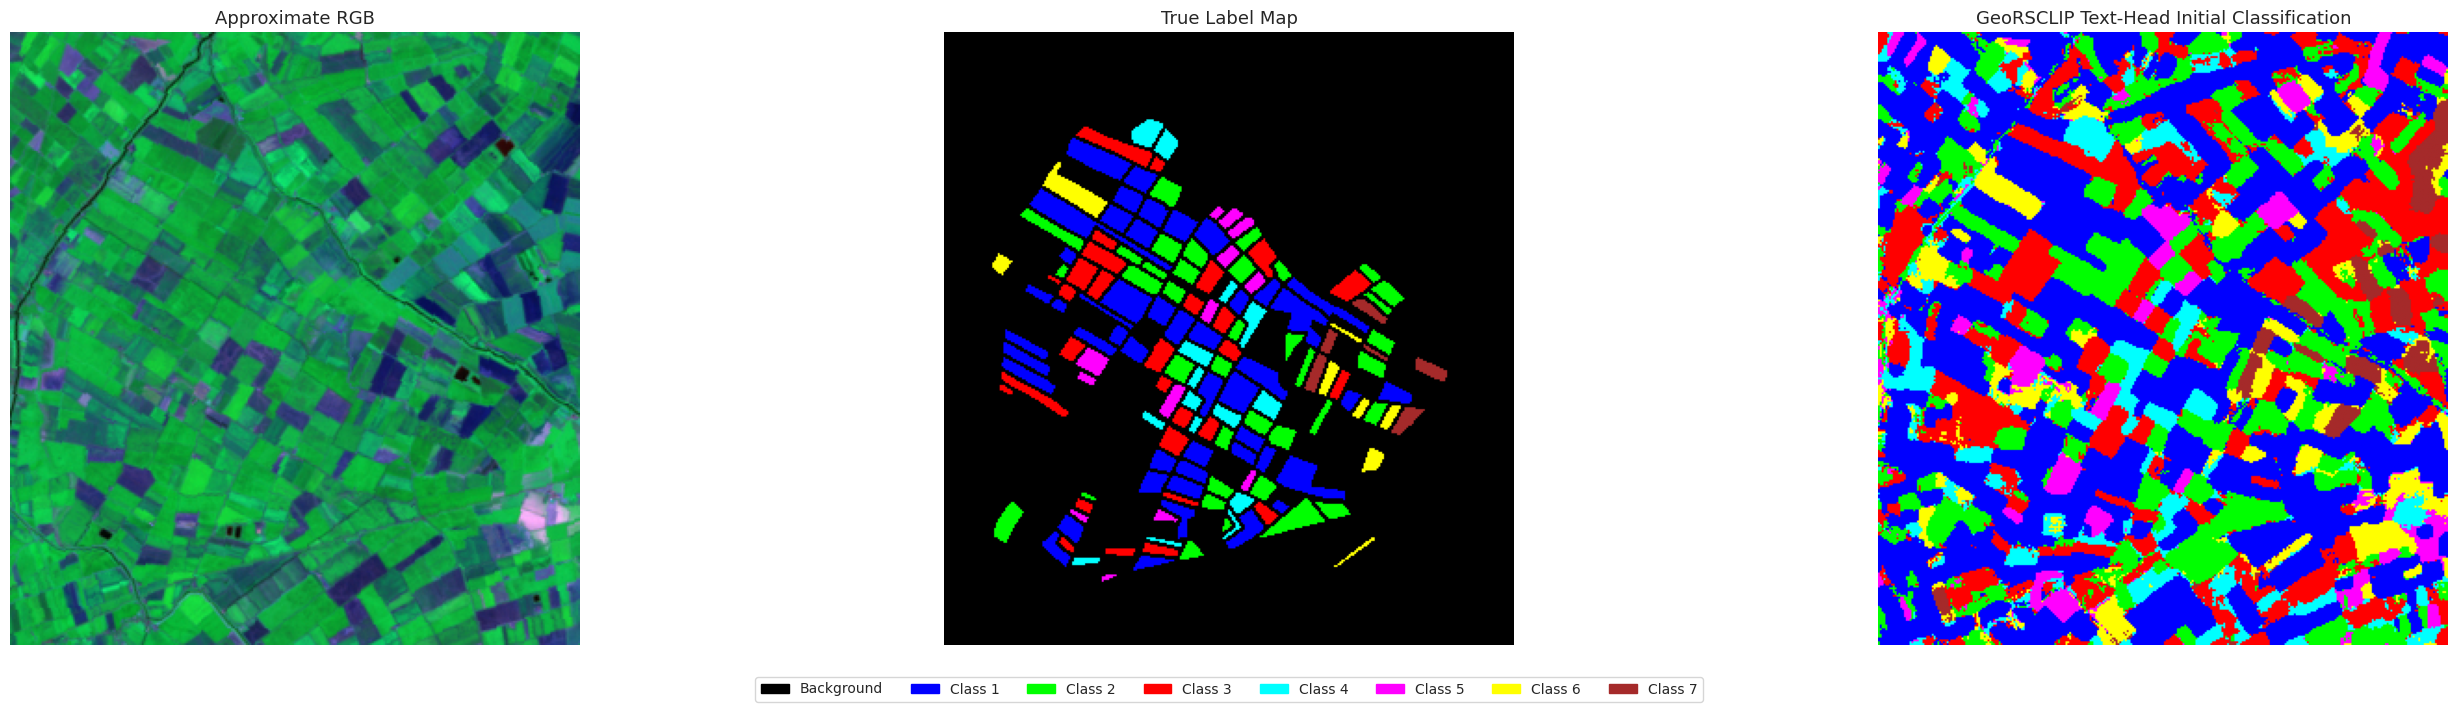

Saved: /content/drive/My Drive/Classification/georsclip/results/scene_visualizations/combined_initial_classification_overview.png
Saved Excel workbook: /content/drive/My Drive/Classification/georsclip/results/scene_visualizations/initial_classification_maps.xlsx
All visualisation outputs saved to: /content/drive/My Drive/Classification/georsclip/results/scene_visualizations


In [20]:
scene_rgb    = get_scene_rgb(x_img, B)
display_cmap = get_display_cmap(num_classes)

loaded_models, missing_models = load_saved_models_for_visualization(MODEL_DIR, CUSTOM_OBJECTS)
prediction_maps = {}

for model_key, loaded_model in loaded_models.items():
    print(f"Generating full-scene classified image for {model_key}...")
    prediction_maps[model_key] = predict_full_scene_labels(
        loaded_model, x_img, patch_size=PATCH_SIZE, batch_size=BATCH_SIZE,
    )
    print(f"{model_key} map shape:", prediction_maps[model_key].shape)

if missing_models:
    print("Some models could not be loaded:")
    for model_key, reason in missing_models.items():
        print(f"  - {model_key}: {reason}")

# Individual PNG paths
rgb_png       = VIS_DIR / "scene_rgb.png"
gt_png        = VIS_DIR / "ground_truth_label_map.png"
georsclip_png = VIS_DIR / "GeoRSCLIP_TextHead_initial_classification.png"
overview_png  = VIS_DIR / "combined_initial_classification_overview.png"

save_single_panel(scene_rgb, "Approximate RGB", rgb_png)
save_single_panel(y_img, "Ground Truth Label Map", gt_png, cmap=display_cmap, vmin=0, vmax=num_classes)

if prediction_maps.get("GeoRSCLIP_TextHead") is not None:
    save_single_panel(prediction_maps["GeoRSCLIP_TextHead"], "GeoRSCLIP Text-Head Initial Classification",
                      georsclip_png, cmap=display_cmap, vmin=0, vmax=num_classes)

save_combined_overview(
    rgb_image=scene_rgb, y_true=y_img, pred_maps=prediction_maps,
    missing_info=missing_models, num_classes=num_classes, save_path=overview_png,
)

image_paths_for_excel = [rgb_png, gt_png, georsclip_png, overview_png]
save_images_to_excel(VIS_EXCEL_PATH, image_paths_for_excel, sheet_name="Initial_Classification_Maps")

print("All visualisation outputs saved to:", VIS_DIR)